<a href="https://www.kaggle.com/code/fiftythirtyfour/predicting-irrigation-need-0-77581?scriptVersionId=311373976" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Load

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/train.csv')

In [2]:
df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [3]:
num = df.select_dtypes('number').columns.to_list()
cat = df.select_dtypes('object').columns.to_list()
target = 'Irrigation_Need'
cat.remove(target)
num.remove('id')

In [4]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=.2)

# Data Science

In [5]:
df[target].value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

In [6]:
cat

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

<Axes: xlabel='Region', ylabel='Soil_Type'>

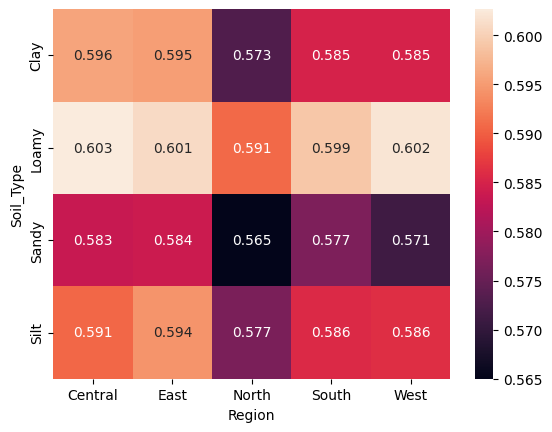

In [7]:
import seaborn as sns

sns.heatmap(
    df.assign(is_low = (df['Irrigation_Need'] == 'Low').astype(int))
      .groupby(['Soil_Type', 'Region'])['is_low']
      .mean()
      .unstack(),
    annot=True,
    fmt=".3f"
)

# Machine

In [8]:
cat

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

In [9]:
num

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [10]:
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm']
cat = ['Crop_Growth_Stage', 'Mulching_Used']

processor = make_column_transformer(
    (make_pipeline(SimpleImputer(), StandardScaler()), num)
    , (OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat)
)

train_pre = processor.fit_transform(train)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

log = LogisticRegression(max_iter=1000)
log.fit(train_pre, train[target])
cross_val_score(log, train_pre, train[target]).mean()

np.float64(0.8748988095238095)

In [12]:
model = log
pipe = make_pipeline(processor, model)

In [13]:
accuracy_score(test[target], pipe.predict(test))

0.8756587301587302

# Submission

In [14]:
samp = pd.read_csv('/kaggle/input/competitions/playground-series-s6e4/test.csv')
pd.DataFrame({
    'id': samp['id']
    , 'Irrigation_Need': pipe.predict(samp)
}).to_csv('submission.csv', index=False)